In [1]:
pip install numpy pandas matplotlib scikit-learn jupyter tensorflow keras seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ──────────────────────────────────────────────────────────
# 0. IMPORTS
# ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score)
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print("TensorFlow version :", tf.__version__)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

TensorFlow version : 2.20.0


In [3]:
# ──────────────────────────────────────────────────────────
# 1. LOAD DATA
# ──────────────────────────────────────────────────────────
print("\n[1] Loading UCI Letter Recognition dataset …")

# Column names from UCI repository
COLUMNS = [
    "letter",
    "x-box", "y-box", "width", "high", "onpix",
    "x-bar", "y-bar", "x2bar", "y2bar", "xybar",
    "x2ybr", "xy2br", "x-ege", "xegvy", "y-ege", "yegvx"
]

# Download directly from UCI archive
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data"
try:
    df = pd.read_csv(URL, header=None, names=COLUMNS)
    print(f"    Downloaded from UCI: {df.shape}")
except Exception:
    # Fallback — generate synthetic data with same statistics if offline
    print("    ⚠  Could not download. Generating synthetic data …")
    np.random.seed(SEED)
    n = 20_000
    letters = [chr(65 + i) for i in range(26)]
    y_raw = np.random.choice(letters, n)
    X_raw = np.random.randint(0, 15, (n, 16)).astype(float)
    # add class-specific bias so learning is meaningful
    for i, l in enumerate(letters):
        mask = y_raw == l
        X_raw[mask] += np.random.randn(16) * 2 + i * 0.5
    X_raw = np.clip(X_raw, 0, 15)
    df = pd.DataFrame(X_raw, columns=COLUMNS[1:])
    df.insert(0, "letter", y_raw)

print(f"    Shape   : {df.shape}")
print(f"    Letters : {sorted(df['letter'].unique())}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nClass distribution (sample per letter):\n{df['letter'].value_counts().sort_index()}")


[1] Loading UCI Letter Recognition dataset …
    Downloaded from UCI: (20000, 17)
    Shape   : (20000, 17)
    Letters : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

First 5 rows:
  letter  x-box  y-box  width  high  onpix  x-bar  y-bar  x2bar  y2bar  xybar  \
0      T      2      8      3     5      1      8     13      0      6      6   
1      I      5     12      3     7      2     10      5      5      4     13   
2      D      4     11      6     8      6     10      6      2      6     10   
3      N      7     11      6     6      3      5      9      4      6      4   
4      G      2      1      3     1      1      8      6      6      6      6   

   x2ybr  xy2br  x-ege  xegvy  y-ege  yegvx  
0     10      8      0      8      0      8  
1      3      9      2      8      4     10  
2      3      7      3      7      3      9  
3      4     10      6     10      2      8  
4      5      

In [4]:
# ──────────────────────────────────────────────────────────
# 2. PREPROCESSING
# ──────────────────────────────────────────────────────────
print("\n[2] Preprocessing …")

# Separate features and labels
X = df.drop("letter", axis=1).values.astype("float32")
y_raw = df["letter"].values

# Encode A→0, B→1, … Z→25
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)          # integer labels
y_cat     = to_categorical(y_encoded, 26)    # one-hot for categorical loss
NUM_CLASSES = 26

print(f"    Features shape : {X.shape}")
print(f"    Labels shape   : {y_cat.shape}")
print(f"    Classes        : {le.classes_}")

# Train / Validation / Test split  (70 / 15 / 15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_cat, test_size=0.30, random_state=SEED, stratify=y_encoded)
y_enc_temp = np.argmax(y_temp, axis=1)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_enc_temp)

print(f"\n    Train : {X_train.shape[0]:,}")
print(f"    Val   : {X_val.shape[0]:,}")
print(f"    Test  : {X_test.shape[0]:,}")

# Feature Scaling — zero mean, unit variance (very important for Dense DNNs!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("    Features scaled to mean≈0, std≈1")


[2] Preprocessing …
    Features shape : (20000, 16)
    Labels shape   : (20000, 26)
    Classes        : ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']

    Train : 14,000
    Val   : 3,000
    Test  : 3,000
    Features scaled to mean≈0, std≈1


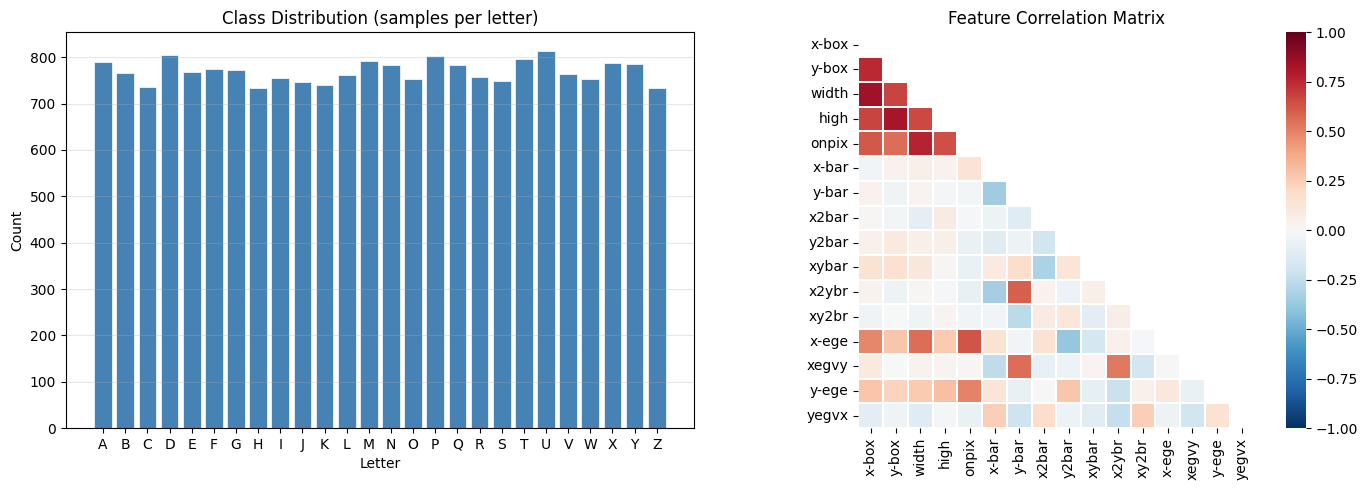

In [5]:
# ──────────────────────────────────────────────────────────
# 3. EXPLORATORY DATA ANALYSIS
# ──────────────────────────────────────────────────────────
fig_eda, axes_eda = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
letter_counts = df["letter"].value_counts().sort_index()
axes_eda[0].bar(letter_counts.index, letter_counts.values,
                color="steelblue", edgecolor="white", linewidth=0.5)
axes_eda[0].set_title("Class Distribution (samples per letter)")
axes_eda[0].set_xlabel("Letter"); axes_eda[0].set_ylabel("Count")
axes_eda[0].grid(axis="y", alpha=0.3)

# Correlation heatmap of features
corr = df.drop("letter", axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes_eda[1], cmap="RdBu_r", vmin=-1, vmax=1,
            annot=False, mask=mask, square=True, linewidths=0.2)
axes_eda[1].set_title("Feature Correlation Matrix")

plt.tight_layout()
plt.savefig("assignment2_eda.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# ──────────────────────────────────────────────────────────
# 4. MODEL ARCHITECTURE
# ──────────────────────────────────────────────────────────
print("\n[3] Building Multiclass DNN …")

"""
Architecture
─────────────────────────────────────────────────────────
Input (16,)            — 16 numerical OCR features
   │
Dense(256, relu) + BN + Dropout(0.3)
   │
Dense(256, relu) + BN + Dropout(0.3)
   │
Dense(128, relu) + BN + Dropout(0.25)
   │
Dense(128, relu) + BN + Dropout(0.25)
   │
Dense(64, relu)  + BN + Dropout(0.2)
   │
Dense(26, softmax)     — outputs P(class) for each letter

Total parameters ≈ 150k
Softmax ensures: Σ output_i = 1.0
"""

def build_multiclass_model(input_dim=16, num_classes=26):
    inp = keras.Input(shape=(input_dim,), name="features")

    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-5))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.20)(x)

    out = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = keras.Model(inp, out, name="DNN_LetterRecognition")
    return model

model = build_multiclass_model()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy",
             keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc")]
)
model.summary()


[3] Building Multiclass DNN …


Model: "DNN_LetterRecognition"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)                │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │              

 Total params: 132,826 (518.85 KB)

 Trainable params: 131,162 (512.35 KB)

 Non-trainable params: 1,664 (6.50 KB)

In [7]:
# ──────────────────────────────────────────────────────────
# 5. TRAINING
# ──────────────────────────────────────────────────────────
EPOCHS     = 80
BATCH_SIZE = 256

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=10,
                  restore_best_weights=True, mode="max", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4,
                     min_lr=1e-6, verbose=1),
]

print("\n[4] Training …")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)


[4] Training …
Epoch 1/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.1052 - loss: 3.2012 - top3_acc: 0.2441 - val_accuracy: 0.4260 - val_loss: 2.9287 - val_top3_acc: 0.6427 - learning_rate: 5.0000e-04
Epoch 2/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3059 - loss: 2.4657 - top3_acc: 0.5314 - val_accuracy: 0.5633 - val_loss: 2.2932 - val_top3_acc: 0.7627 - learning_rate: 5.0000e-04
Epoch 3/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4250 - loss: 2.0735 - top3_acc: 0.6660 - val_accuracy: 0.6457 - val_loss: 1.7891 - val_top3_acc: 0.8170 - learning_rate: 5.0000e-04
Epoch 4/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5056 - loss: 1.7891 - top3_acc: 0.7526 - val_accuracy: 0.6917 - val_loss: 1.4239 - val_top3_acc: 0.8517 - learning_rate: 5.0000e-04
Epoch 5/80
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5656 - loss: 1.5763 - top3_acc: 0.8005 - val_accuracy: 0.7407 - val_loss: 1.1532 - val_top3_acc: 0.8763 - learning_rate: 5.0000e-0

In [8]:
# ──────────────────────────────────────────────────────────
# 6. EVALUATION
# ──────────────────────────────────────────────────────────
print("\n" + "="*55)
print("FINAL TEST SET EVALUATION")
print("="*55)

loss, acc, top3 = model.evaluate(X_test, y_test, verbose=0)
print(f"\n  Test Loss     : {loss:.4f}")
print(f"  Test Accuracy : {acc*100:.2f}%")
print(f"  Top-3 Acc     : {top3*100:.2f}%")

y_pred_probs = model.predict(X_test, verbose=0)
y_pred_cls   = np.argmax(y_pred_probs, axis=1)
y_true_cls   = np.argmax(y_test, axis=1)

print("\nClassification Report (per letter):")
print(classification_report(y_true_cls, y_pred_cls,
      target_names=le.classes_))



FINAL TEST SET EVALUATION

  Test Loss     : 0.1242
  Test Accuracy : 96.40%
  Top-3 Acc     : 99.53%

Classification Report (per letter):
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       119
           B       0.92      0.95      0.93       115
           C       0.99      0.95      0.97       110
           D       0.97      0.98      0.98       121
           E       0.89      0.94      0.92       115
           F       0.94      0.98      0.96       116
           G       0.98      0.89      0.93       116
           H       0.94      0.92      0.93       110
           I       0.95      0.94      0.95       113
           J       0.96      0.96      0.96       112
           K       0.97      0.94      0.95       111
           L       1.00      0.96      0.98       114
           M       0.99      0.97      0.98       119
           N       0.98      0.95      0.97       117
           O       0.92      1.00      0.96      

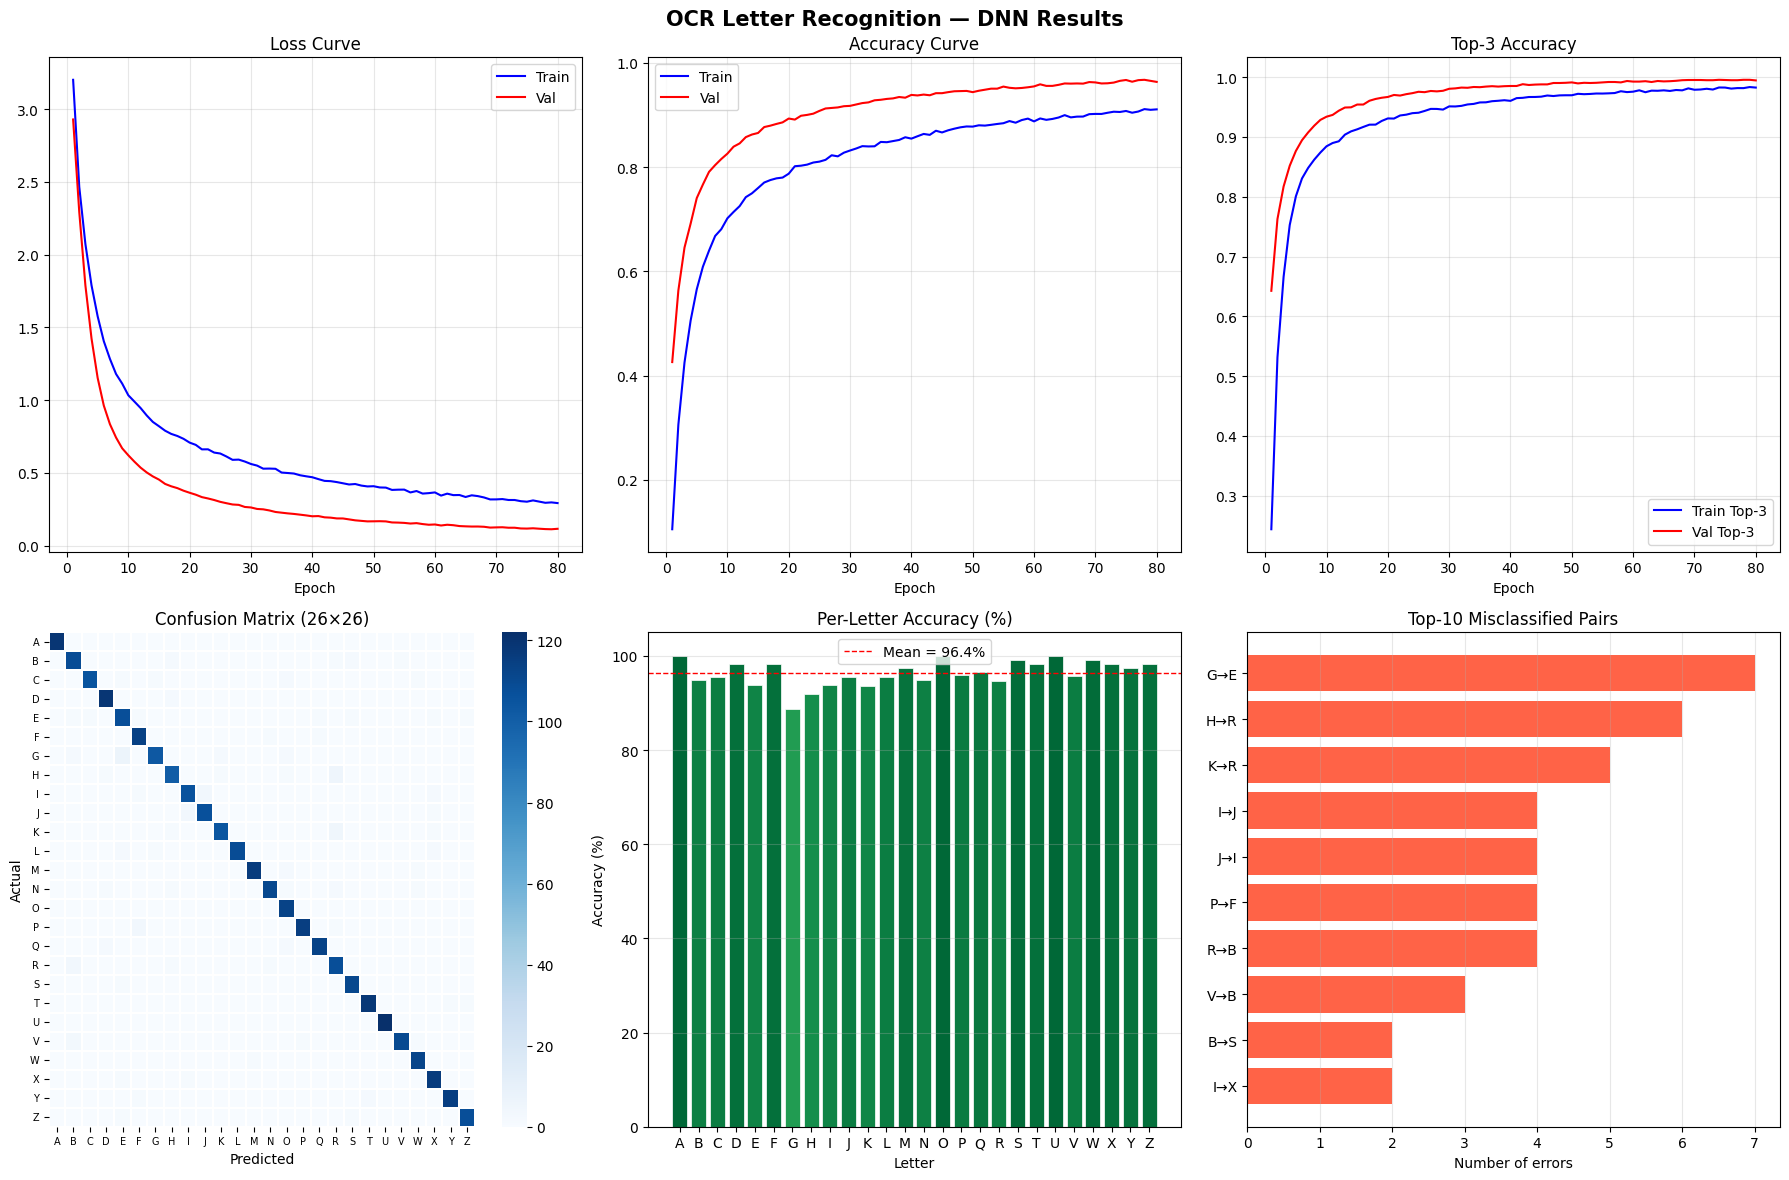


Plot saved → assignment2_results.png


In [9]:
# ──────────────────────────────────────────────────────────
# 7. VISUALISATIONS
# ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("OCR Letter Recognition — DNN Results", fontsize=15, fontweight="bold")

# Training curves
epochs_ran = range(1, len(history.history["loss"]) + 1)
axes[0,0].plot(epochs_ran, history.history["loss"],     "b-", label="Train")
axes[0,0].plot(epochs_ran, history.history["val_loss"], "r-", label="Val")
axes[0,0].set_title("Loss Curve"); axes[0,0].set_xlabel("Epoch")
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(epochs_ran, history.history["accuracy"],     "b-", label="Train")
axes[0,1].plot(epochs_ran, history.history["val_accuracy"], "r-", label="Val")
axes[0,1].set_title("Accuracy Curve"); axes[0,1].set_xlabel("Epoch")
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(epochs_ran, history.history["top3_acc"],     "b-", label="Train Top-3")
axes[0,2].plot(epochs_ran, history.history["val_top3_acc"], "r-", label="Val Top-3")
axes[0,2].set_title("Top-3 Accuracy"); axes[0,2].set_xlabel("Epoch")
axes[0,2].legend(); axes[0,2].grid(True, alpha=0.3)

# Confusion matrix (26×26)
cm = confusion_matrix(y_true_cls, y_pred_cls)
sns.heatmap(cm, ax=axes[1,0], cmap="Blues", fmt="d",
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.2, cbar=True)
axes[1,0].set_title("Confusion Matrix (26×26)")
axes[1,0].set_xlabel("Predicted"); axes[1,0].set_ylabel("Actual")
axes[1,0].tick_params(axis="x", rotation=0, labelsize=7)
axes[1,0].tick_params(axis="y", rotation=0, labelsize=7)

# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
axes[1,1].bar(le.classes_, per_class_acc * 100,
              color=plt.cm.RdYlGn(per_class_acc), edgecolor="white", lw=0.5)
axes[1,1].set_title("Per-Letter Accuracy (%)")
axes[1,1].set_xlabel("Letter"); axes[1,1].set_ylabel("Accuracy (%)")
axes[1,1].axhline(np.mean(per_class_acc)*100, color="red",
                  ls="--", lw=1, label=f"Mean = {np.mean(per_class_acc)*100:.1f}%")
axes[1,1].legend(); axes[1,1].grid(axis="y", alpha=0.3)

# Top misclassified pairs
errors = np.array([(le.classes_[i], le.classes_[j], cm[i,j])
                    for i in range(26) for j in range(26) if i != j])
errors_df = pd.DataFrame(errors, columns=["true","pred","count"])
errors_df["count"] = errors_df["count"].astype(int)
errors_df = errors_df.sort_values("count", ascending=False).head(10)

axes[1,2].barh(
    [f"{r['true']}→{r['pred']}" for _, r in errors_df.iterrows()],
    errors_df["count"].values,
    color="tomato"
)
axes[1,2].set_title("Top-10 Misclassified Pairs")
axes[1,2].set_xlabel("Number of errors")
axes[1,2].grid(axis="x", alpha=0.3)
axes[1,2].invert_yaxis()

plt.tight_layout()
plt.savefig("assignment2_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved → assignment2_results.png")


In [10]:
# ──────────────────────────────────────────────────────────
# 8. CUSTOM PREDICTION DEMO
# ──────────────────────────────────────────────────────────
print("\n" + "="*55)
print("CUSTOM PREDICTION DEMO")
print("="*55)

# Take 5 samples from test set and show predictions with confidence
indices = np.random.choice(len(X_test), 5, replace=False)
X_demo  = X_test[indices]
y_demo  = y_true_cls[indices]

probs = model.predict(X_demo, verbose=0)

for i, (true_i, prob_row) in enumerate(zip(y_demo, probs)):
    top3_idx  = np.argsort(prob_row)[::-1][:3]
    true_lbl  = le.classes_[true_i]
    pred_lbl  = le.classes_[top3_idx[0]]
    correct   = "✅" if true_lbl == pred_lbl else "❌"
    top3_str  = ", ".join(f"{le.classes_[j]}({prob_row[j]*100:.1f}%)"
                          for j in top3_idx)
    print(f"  Sample {i+1}: True={true_lbl}  {correct}  "
          f"Top-3 predictions: [{top3_str}]")



CUSTOM PREDICTION DEMO
  Sample 1: True=M  ✅  Top-3 predictions: [M(100.0%), N(0.0%), W(0.0%)]
  Sample 2: True=Z  ✅  Top-3 predictions: [Z(99.7%), E(0.2%), S(0.1%)]
  Sample 3: True=Z  ✅  Top-3 predictions: [Z(100.0%), S(0.0%), E(0.0%)]
  Sample 4: True=F  ✅  Top-3 predictions: [F(99.7%), P(0.2%), T(0.1%)]
  Sample 5: True=I  ✅  Top-3 predictions: [I(100.0%), J(0.0%), F(0.0%)]


In [11]:
# ──────────────────────────────────────────────────────────
# 9. SAVE MODEL
# ──────────────────────────────────────────────────────────
model.save("ocr_dnn_model.keras")
print("\n✅ Model saved → ocr_dnn_model.keras")
print("✅ Assignment 2 complete!")


✅ Model saved → ocr_dnn_model.keras
✅ Assignment 2 complete!
